In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Get the data
ticker_value = 'SPY'
ticker = yf.Ticker(ticker_value)
df = ticker.history(period="2y")

In [4]:
def calculate_mfi(df, period=14):
    """
    Calculate Money Flow Index
    
    Parameters:
    df (pandas.DataFrame): DataFrame with OHLCV data
    period (int): Look-back period for calculations
    
    Returns:
    pandas.Series: Money Flow Index values
    """
    # Calculate typical price
    typical_price = (df['High'] + df['Low'] + df['Close']) / 3
    
    # Calculate raw money flow
    raw_money_flow = typical_price * df['Volume']
    
    # Get the price change
    price_change = typical_price.diff()
    
    # Separate positive and negative money flow
    positive_flow = pd.Series(0, index=df.index)
    negative_flow = pd.Series(0, index=df.index)
    
    # When price rises, count as positive flow
    positive_flow[price_change > 0] = raw_money_flow[price_change > 0]
    # When price falls, count as negative flow
    negative_flow[price_change < 0] = raw_money_flow[price_change < 0]
    
    # Calculate money flow ratio
    positive_mf = positive_flow.rolling(window=period).sum()
    negative_mf = negative_flow.rolling(window=period).sum()
    
    money_flow_ratio = positive_mf / negative_mf
    
    # Calculate MFI
    mfi = 100 - (100 / (1 + money_flow_ratio))
    
    return mfi

/var/folders/q8/v7x1ldw54bl3k_m548drsx1h0000gn/T/ipykernel_18431/1981678527.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2.21991042e+10 1.91542564e+10 2.48996121e+10 2.77858727e+10
 3.20272528e+10 3.90708098e+10 2.80411244e+10 2.64054471e+10
 3.47187441e+10 2.46722951e+10 2.42824411e+10 3.51283458e+10
 3.27200738e+10 2.83486617e+10 2.69710080e+10 3.41594634e+10
 4.03519562e+10 4.11266281e+10 3.65551231e+10 2.59690775e+10
 3.54226278e+10 2.46950156e+10 3.74125952e+10 3.11843995e+10
 3.28082814e+10 3.52826977e+10 2.86951047e+10 5.69087365e+10
 5.47476649e+10 3.56720468e+10 3.55590771e+10 2.86840339e+10
 3.03045155e+10 2.74959046e+10 4.46232308e+10 2.69912259e+10
 2.53972538e+10 2.53914958e+10 2.37316282e+10 3.44969964e+10
 3.14791737e+10 2.67867829e+10 2.57039783e+10 2.58820285e+10
 3.72680151e+10 3.61449072e+10 2.52375905e+10 3.53038654e+10
 2.01504108e+10 3.86788616e+10 2.18481934e+10 3.52714535e+10
 3.964

<Figure size 1500x1000 with 0 Axes>

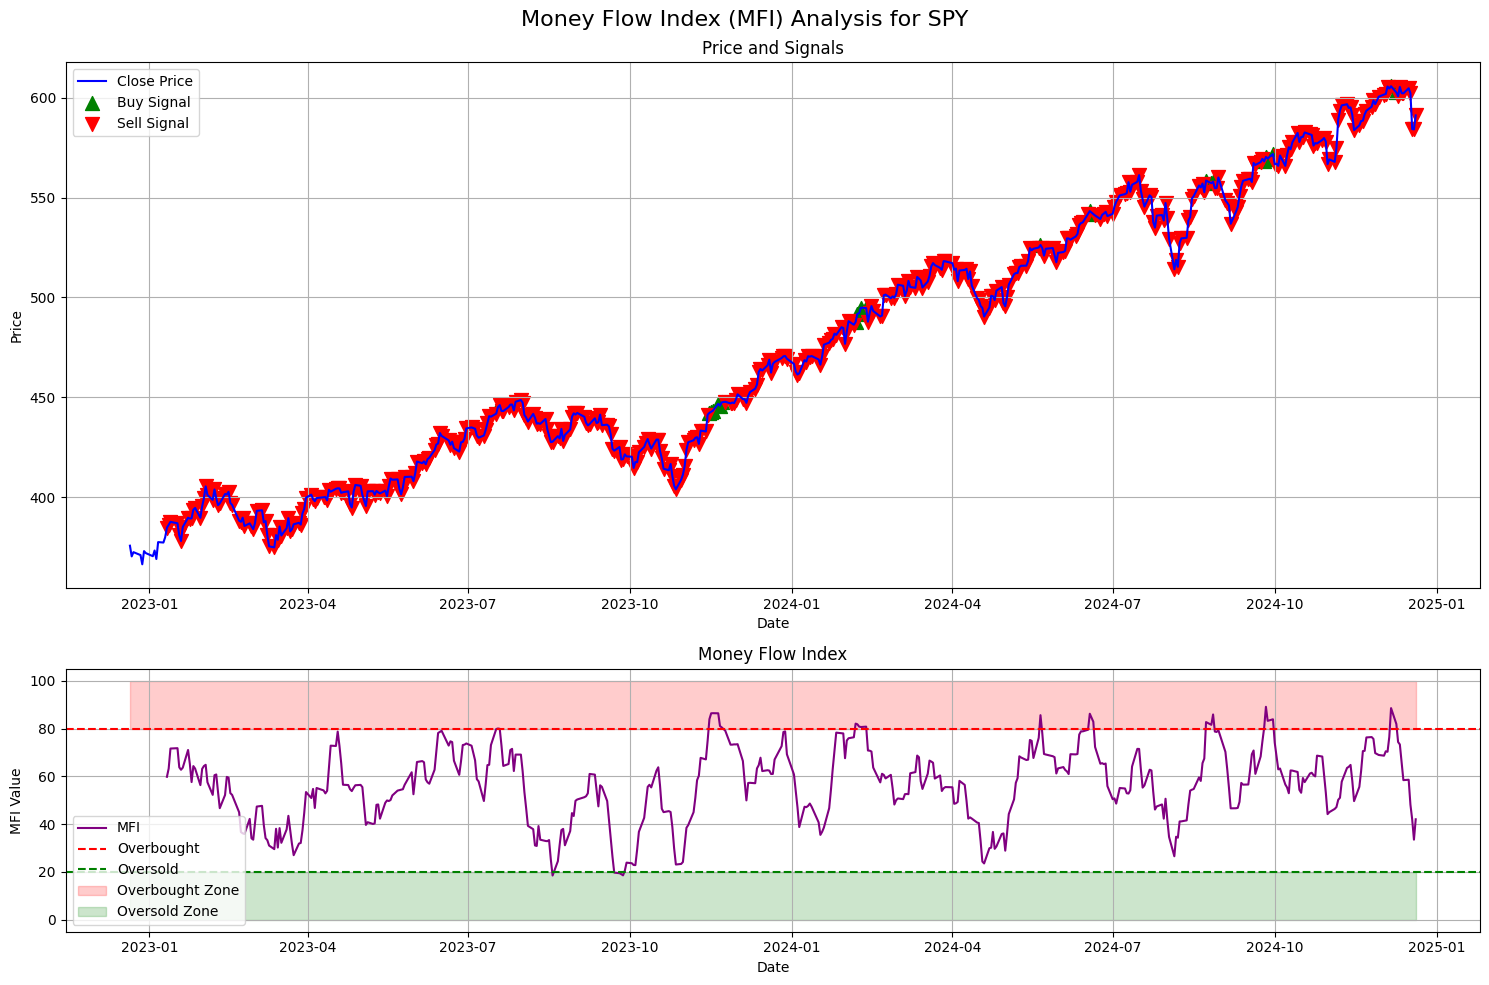


MFI Analysis Summary:
Current MFI Value: 42.04
Number of Buy Signals: 24
Number of Sell Signals: 466


In [5]:
# Calculate MFI
df['MFI'] = calculate_mfi(df)

# Generate buy/sell signals
df['Signal'] = 0  # 0 represents no signal
overbought_threshold = 80
oversold_threshold = 20

# Buy signal when MFI crosses above oversold threshold
df.loc[df['MFI'] > oversold_threshold, 'Signal'] = 1

# Sell signal when MFI crosses below overbought threshold
df.loc[df['MFI'] < overbought_threshold, 'Signal'] = -1

# Plotting
plt.figure(figsize=(15, 10))

# Create two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), height_ratios=[2, 1])
fig.suptitle(f'Money Flow Index (MFI) Analysis for {ticker_value}', fontsize=16)

# Plot price
ax1.plot(df.index, df['Close'], label='Close Price', color='blue')

# Plot buy signals
buy_signals = df[df['Signal'] == 1]
ax1.scatter(buy_signals.index, buy_signals['Close'], 
           color='green', marker='^', s=100, label='Buy Signal')

# Plot sell signals
sell_signals = df[df['Signal'] == -1]
ax1.scatter(sell_signals.index, sell_signals['Close'], 
           color='red', marker='v', s=100, label='Sell Signal')

ax1.set_title('Price and Signals')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)

# Plot MFI
ax2.plot(df.index, df['MFI'], label='MFI', color='purple')
ax2.axhline(y=overbought_threshold, color='r', linestyle='--', label='Overbought')
ax2.axhline(y=oversold_threshold, color='g', linestyle='--', label='Oversold')
ax2.fill_between(df.index, y1=overbought_threshold, y2=100, 
                 alpha=0.2, color='r', label='Overbought Zone')
ax2.fill_between(df.index, y1=0, y2=oversold_threshold, 
                 alpha=0.2, color='g', label='Oversold Zone')

ax2.set_title('Money Flow Index')
ax2.set_xlabel('Date')
ax2.set_ylabel('MFI Value')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print some statistics
print("\nMFI Analysis Summary:")
print(f"Current MFI Value: {df['MFI'].iloc[-1]:.2f}")
print(f"Number of Buy Signals: {len(buy_signals)}")
print(f"Number of Sell Signals: {len(sell_signals)}")